In [1]:
import pandas as pd
import numpy as np
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

print(f"Numpy version: {np.__version__}")
print("¡Importación exitosa!")
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.api import ExponentialSmoothing
from tabulate import tabulate
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

Numpy version: 1.26.4
¡Importación exitosa!


## 1. Introducción: Presentación de la serie a analizar.

Cargamos los datos del fichero `hielo_artico_master.csv`. La variable de interés es `extent` que representa la extensión del hielo.
Vamos a convertir la columna de fecha al formato adecuado y establecerla como índice.

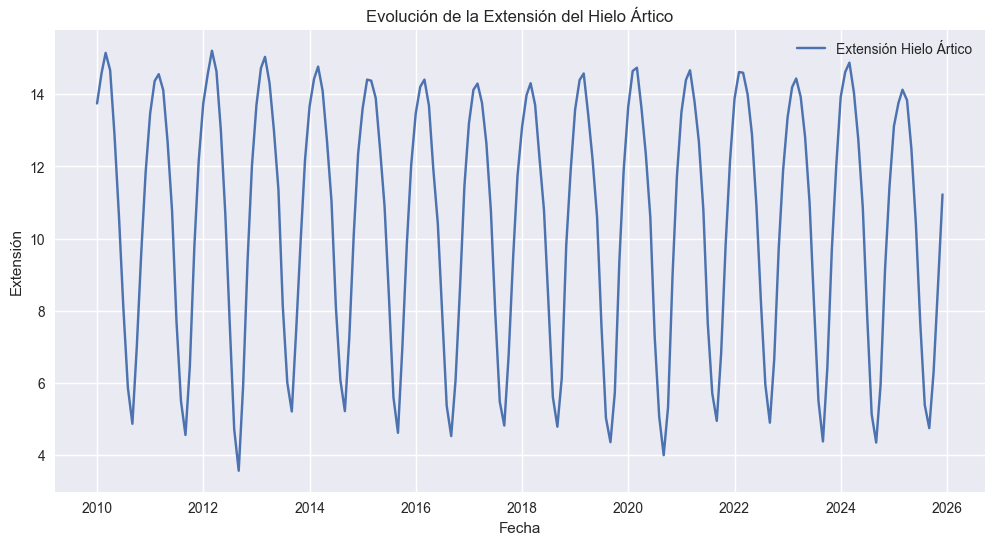

In [2]:
df = pd.read_csv('hielo_artico_master.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Asignamos frecuencia mensual (Month Start)
df.index.freq = 'MS'

# Representación gráfica inicial
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['extent'], label='Extensión Hielo Ártico')
plt.title('Evolución de la Extensión del Hielo Ártico')
plt.xlabel('Fecha')
plt.ylabel('Extensión')
plt.legend()
plt.show()

A primera vista, observamos una clara estacionalidad anual: el hielo crece en invierno y disminuye en verano.
También parece haber una ligera tendencia decreciente a lo largo de los años, lo cual es consistente con el calentamiento global.

## 2. Representación gráfica y descomposición estacional

Vamos a descomponer la serie en sus componentes: Tendencia, Estacionalidad y Residuo.
Dado que la amplitud de las oscilaciones estacionales parece mantenerse constante (no crece con el tiempo), utilizaremos un modelo **aditivo**.
Y_t = Tendencia_t + Estacionalidad_t + Residuo_t

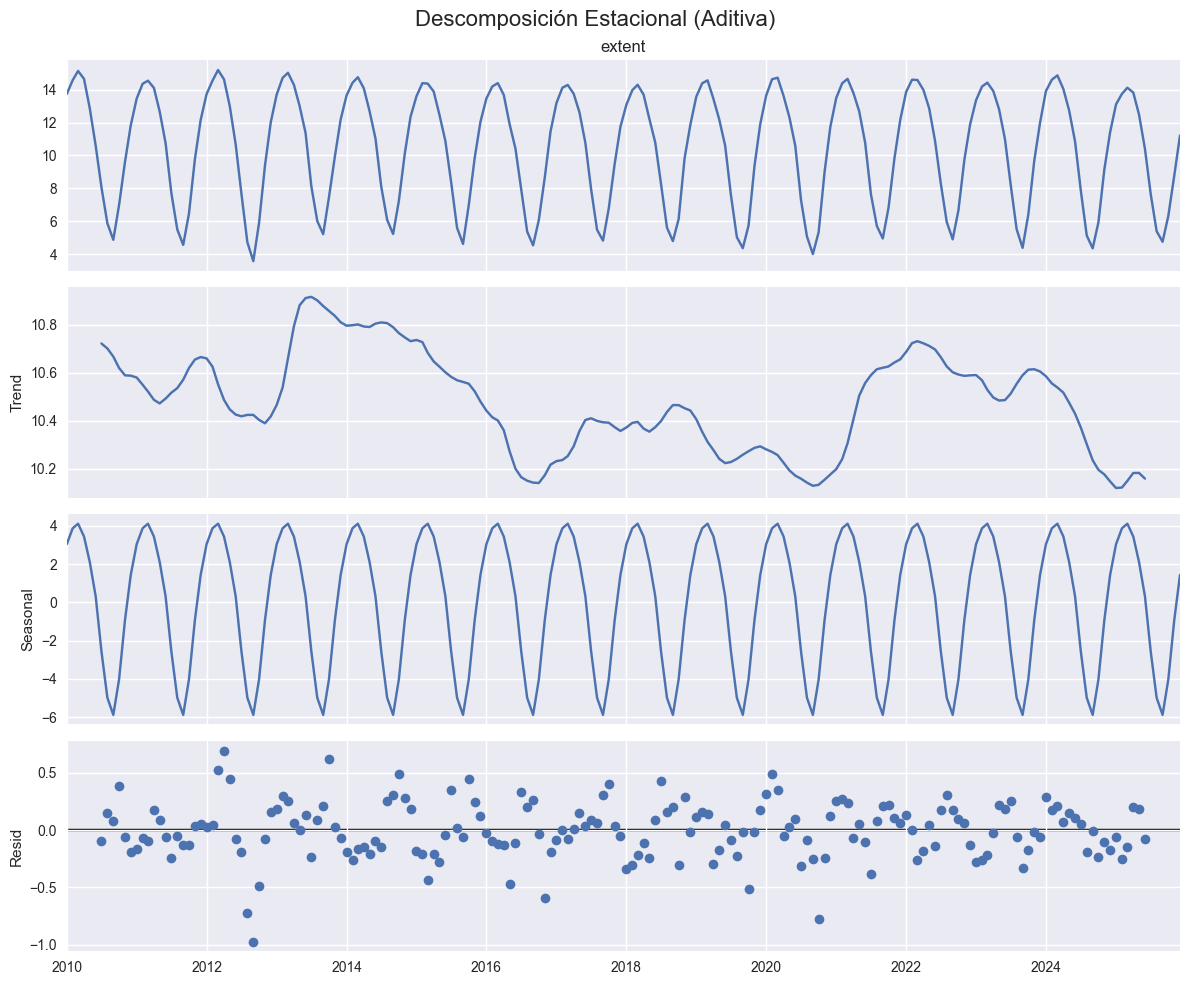

In [3]:
# Descomposición estacional (Modelo Aditivo)
decomposition = seasonal_decompose(df['extent'], model='additive')

# Gráfico de la descomposición
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Descomposición Estacional (Aditiva)', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# Tabla de coeficientes de estacionalidad
# Como es una serie mensual, los coeficientes se repiten cada 12 meses. Mostramos un ciclo completo.
seasonal_coeffs = decomposition.seasonal.head(12)
seasonal_df = pd.DataFrame(seasonal_coeffs)
seasonal_df.columns = ['Coeficiente Estacional']
seasonal_df.index.name = 'Mes'
# Extraemos el nombre del mes para mejor interpretación
seasonal_df['Nombre Mes'] = seasonal_df.index.month_name()

print("\nTabla de Coeficientes de Estacionalidad (para un año tipo):")
print(seasonal_df[['Nombre Mes', 'Coeficiente Estacional']])

# Interpretación
print("\nInterpretación:")
print("Los coeficientes positivos indican los meses donde la extensión es superior a la media de la tendencia (Invierno/Primavera).")
print("Los coeficientes negativos indican los meses de deshielo (Verano/Otoño).")
print(f"El máximo estacional ocurre en: {seasonal_df.sort_values('Coeficiente Estacional', ascending=False).iloc[0]['Nombre Mes']}")
print(f"El mínimo estacional ocurre en: {seasonal_df.sort_values('Coeficiente Estacional', ascending=True).iloc[0]['Nombre Mes']}")



Tabla de Coeficientes de Estacionalidad (para un año tipo):
           Nombre Mes  Coeficiente Estacional
Mes                                          
2010-01-01    January                3.046380
2010-02-01   February                3.880852
2010-03-01      March                4.119185
2010-04-01      April                3.448019
2010-05-01        May                2.119519
2010-06-01       June                0.318880
2010-07-01       July               -2.555231
2010-08-01     August               -4.983843
2010-09-01  September               -5.879370
2010-10-01    October               -4.026898
2010-11-01   November               -0.921537
2010-12-01   December                1.434046

Interpretación:
Los coeficientes positivos indican los meses donde la extensión es superior a la media de la tendencia (Invierno/Primavera).
Los coeficientes negativos indican los meses de deshielo (Verano/Otoño).
El máximo estacional ocurre en: March
El mínimo estacional ocurre en: September


## 3. División en TRAIN y TEST

Para validar nuestros modelos, reservaremos los últimos datos observados.
Al ser una serie estacional mensual, reservaremos un ciclo completo, es decir, **12 meses**.

**TRAIN:** Datos para ajustar los modelos.
**TEST:** Últimos 12 meses para comprobar las predicciones.

Tamaño total: 192
Tamaño TRAIN: 180
Tamaño TEST: 12

Fecha inicio TEST: 2025-01-01 00:00:00
Fecha fin TEST: 2025-12-01 00:00:00


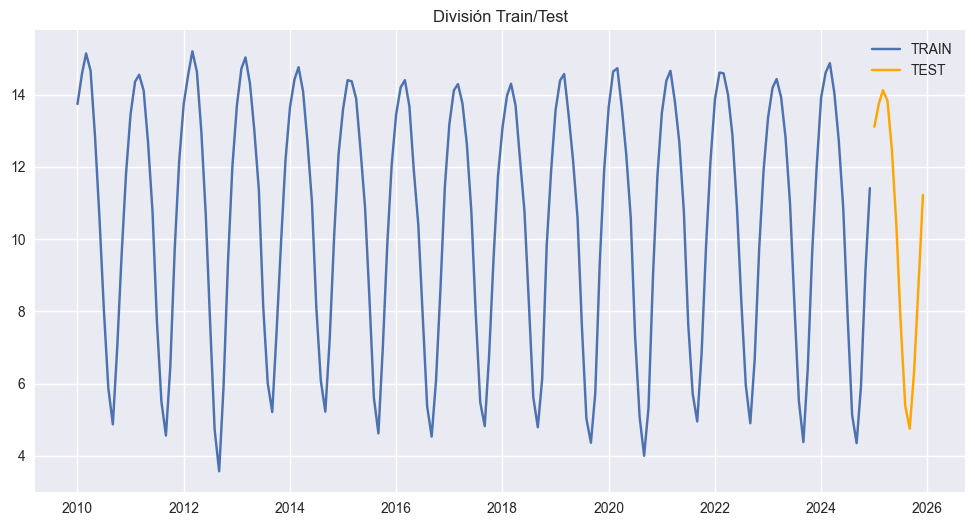

In [5]:
test_size = 12
train = df['extent'].iloc[:-test_size]
test = df['extent'].iloc[-test_size:]

print(f"Tamaño total: {len(df)}")
print(f"Tamaño TRAIN: {len(train)}")
print(f"Tamaño TEST: {len(test)}")
print(f"\nFecha inicio TEST: {test.index[0]}")
print(f"Fecha fin TEST: {test.index[-1]}")

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='TRAIN')
plt.plot(test.index, test, label='TEST', color='orange')
plt.title('División Train/Test')
plt.legend()
plt.show()

## 4. Modelo de Suavizado Exponencial (Holt-Winters)

Probaremos varios modelos de suavizado exponencial para encontrar el que tenga el menor criterio de información (AIC).
Consideraremos las componentes de Tendencia y Estacionalidad.

### Modelos a probar:
1.  Tendencia Aditiva, Estacionalidad Aditiva (AAA)
2.  Tendencia Aditiva, Estacionalidad Multiplicativa (AAM)
3.  Tendencia Aditiva Amortiguada, Estacionalidad Aditiva (DAA)

Nota: Dado que tenemos ceros o valores negativos en los residuos si usamos multiplicativo puede dar problemas, pero la serie 'extent' es positiva, así que probaremos.


In [6]:
# --- PRUEBA DE HIPÓTESIS: Ajuste manual de 3 modelos ---

# Modelo 1: AAA (Tendencia Aditiva, Estacionalidad Aditiva)
modelo_aaa = ExponentialSmoothing(
    train, 
    seasonal_periods=12, 
    trend="add", 
    seasonal="add", 
    initialization_method="estimated"
).fit()

# Modelo 2: AAM (Tendencia Aditiva, Estacionalidad Multiplicativa)
modelo_aam = ExponentialSmoothing(
    train, 
    seasonal_periods=12, 
    trend="add", 
    seasonal="mul", 
    initialization_method="estimated"
).fit()

# Modelo 3: DAA (Tendencia Aditiva Amortiguada, Estacionalidad Aditiva)
modelo_daa = ExponentialSmoothing(
    train, 
    seasonal_periods=12, 
    trend="add", 
    seasonal="add", 
    damped_trend=True, 
    initialization_method="estimated"
).fit()

# --- COMPARACIÓN DE CRITERIOS (AIC) ---
print("--- Comparativa de Modelos (Criterio AIC) ---")
print(f"AIC Modelo AAA (Aditivo-Aditivo): {modelo_aaa.aic:.2f}")
print(f"AIC Modelo AAM (Aditivo-Multiplicativo): {modelo_aam.aic:.2f}")
print(f"AIC Modelo DAA (Amortiguado-Aditivo): {modelo_daa.aic:.2f}\n")

--- Comparativa de Modelos (Criterio AIC) ---
AIC Modelo AAA (Aditivo-Aditivo): -473.68
AIC Modelo AAM (Aditivo-Multiplicativo): -415.41
AIC Modelo DAA (Amortiguado-Aditivo): -471.67



In [7]:
# --- SELECCIÓN DEL MODELO GANADOR ---
modelo_hw_final = modelo_aaa 

# Extraer y mostrar los parámetros estadísticos del modelo ganador
headers = ['Name', 'Param', 'Value', 'Optimized']
table_str = tabulate(modelo_hw_final.params_formatted, headers, tablefmt='fancy_grid')
print("Parámetros del modelo Holt-Winters ganador:")
print(table_str)

Parámetros del modelo Holt-Winters ganador:
╒════════════════════╤═════════╤════════════╤═════════════╕
│ Name               │ Param   │      Value │ Optimized   │
╞════════════════════╪═════════╪════════════╪═════════════╡
│ smoothing_level    │ alpha   │  0.933702  │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ smoothing_trend    │ beta    │  0         │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ smoothing_seasonal │ gamma   │  0.0662977 │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ initial_level      │ l.0     │ 10.7021    │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ initial_trend      │ b.0     │ -0.0040968 │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ initial_seasons.0  │ s.0     │  3.04196   │ True        │
├────────────────────┼─────────┼────────────┼─────────────┤
│ initial_seasons.1  │ s.1     │  3.85023   │ True      

In [8]:
predictions_ets = modelo_hw_final.forecast(len(test))

tabla_resultados = pd.DataFrame({
    'Observado': test,
    'Predicción ETS': predictions_ets
})

# Cálculo del Error (resta directa, conservando positivos y negativos)
tabla_resultados['Error'] = tabla_resultados['Observado'] - tabla_resultados['Predicción ETS']

print("--- TABLA DE PREDICCIONES Y ERRORES (TEST) ---")
print(tabla_resultados)

--- TABLA DE PREDICCIONES Y ERRORES (TEST) ---
            Observado  Predicción ETS     Error
2025-01-01      13.11       13.026457  0.083543
2025-02-01      13.75       13.824465 -0.074465
2025-03-01      14.12       14.051653  0.068347
2025-04-01      13.83       13.388744  0.441256
2025-05-01      12.49       12.104208  0.385792
2025-06-01      10.40       10.252994  0.147006
2025-07-01       7.66        7.373146  0.286854
2025-08-01       5.39        4.929445  0.460555
2025-09-01       4.75        4.024743  0.725257
2025-10-01       6.32        5.849637  0.470363
2025-11-01       8.77        9.035160 -0.265160
2025-12-01      11.22       11.365502 -0.145502


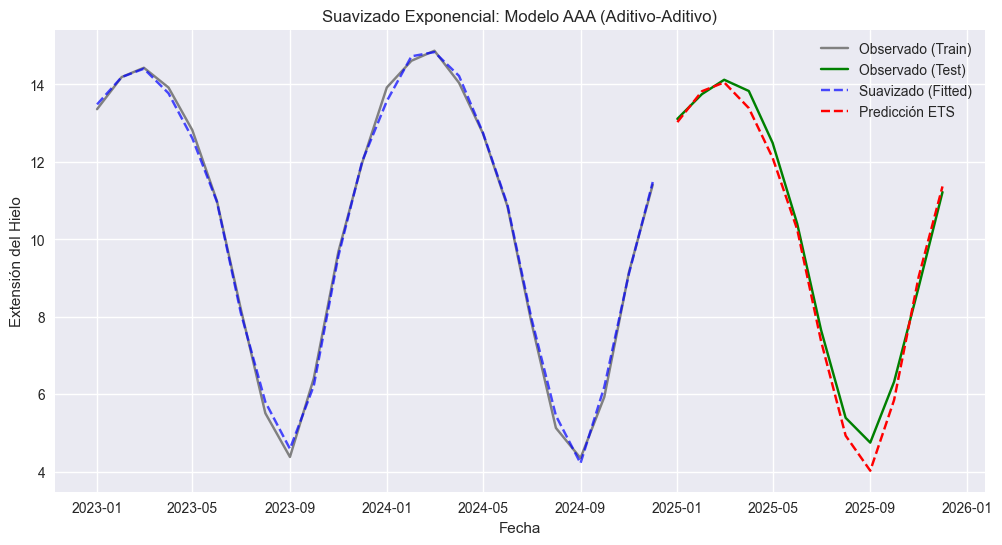

In [9]:
# Mostramos el final de train (últimos 24 meses) para ver la continuidad
plt.plot(train.index[-24:], train.iloc[-24:], label='Observado (Train)', color='gray') 
plt.plot(test.index, test, label='Observado (Test)', color='green')

# Dibujamos los valores suavizados por el modelo para esos mismos 24 meses
plt.plot(modelo_hw_final.fittedvalues.index[-24:], modelo_hw_final.fittedvalues.iloc[-24:], 
         label='Suavizado (Fitted)', color='blue', linestyle='--', alpha=0.7)

# Dibujamos las predicciones futuras (periodo test)
plt.plot(predictions_ets.index, predictions_ets, label='Predicción ETS', color='red', linestyle='--')

plt.title('Suavizado Exponencial: Modelo AAA (Aditivo-Aditivo)')
plt.xlabel('Fecha')
plt.ylabel('Extensión del Hielo')
plt.legend()
plt.show()

Hemos ajustado un modelo Holt-Winters. La gráfica muestra cómo el modelo captura bien la estacionalidad y se ajusta a los datos de test, aunque veremos más adelante cómo compara numéricamente con otros métodos.

## 5. Identificación y Ajuste de Modelo ARIMA Manual
Analizamos la estacionariedad y la estructura de autocorrelación para determinar los parámetros (p,d,q) y (P,D,Q)s.

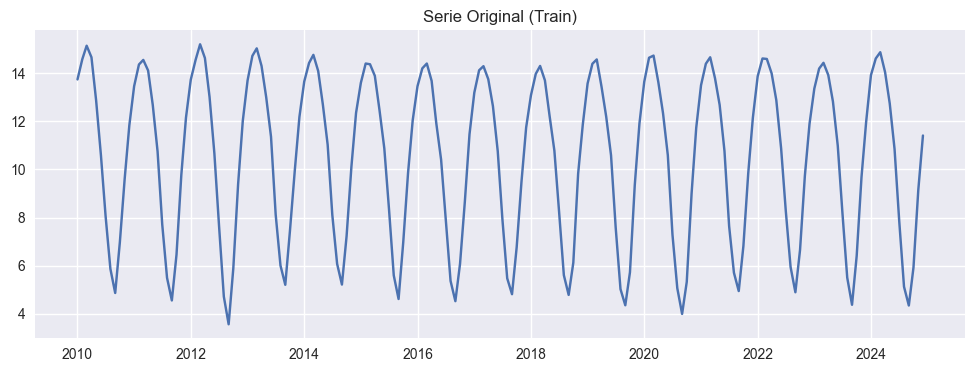

In [10]:
# Graficamos la serie original para ver tendencia y estacionalidad
plt.figure(figsize=(12, 4))
plt.plot(train)
plt.title('Serie Original (Train)')
plt.show()

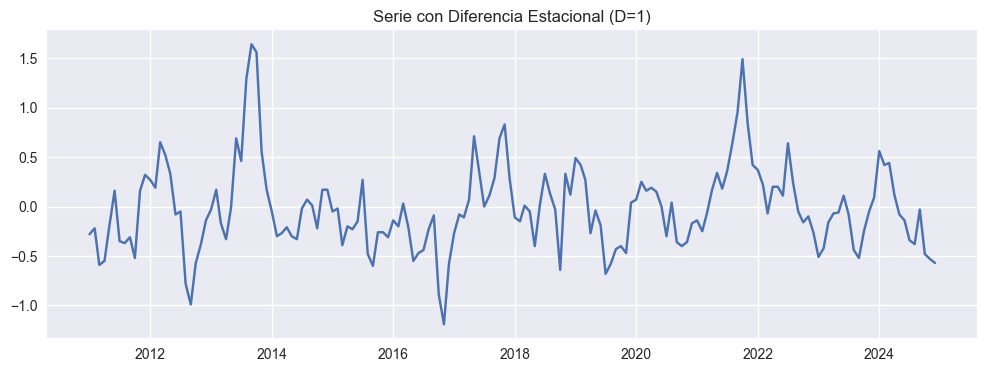

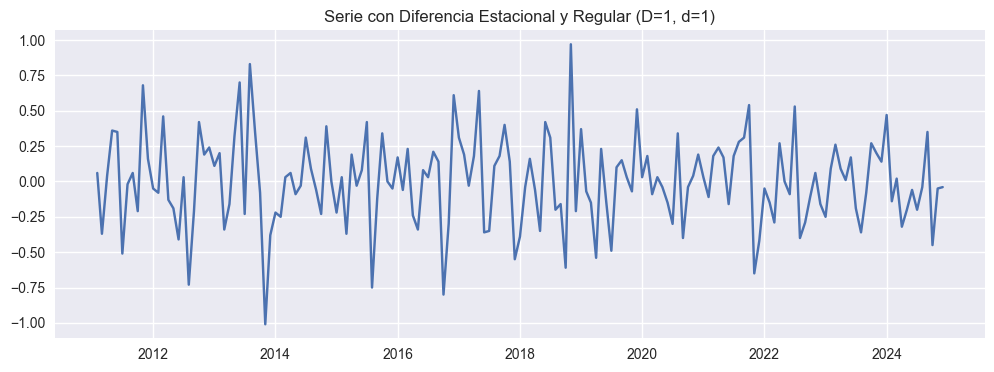

In [11]:
# Diferenciación
# Dada la tendencia y estacionalidad anual (s=12), probamos primero con una diferencia estacional y luego una regular.
# Generalmente: D=1 (estacional), d=1 (regular) es común en series mensuales con tendencia.

train_diff_12 = train.diff(12).dropna()
plt.figure(figsize=(12, 4))
plt.plot(train_diff_12)
plt.title('Serie con Diferencia Estacional (D=1)')
plt.show()

train_diff_12_1 = train_diff_12.diff(1).dropna()
plt.figure(figsize=(12, 4))
plt.plot(train_diff_12_1)
plt.title('Serie con Diferencia Estacional y Regular (D=1, d=1)')
plt.show()

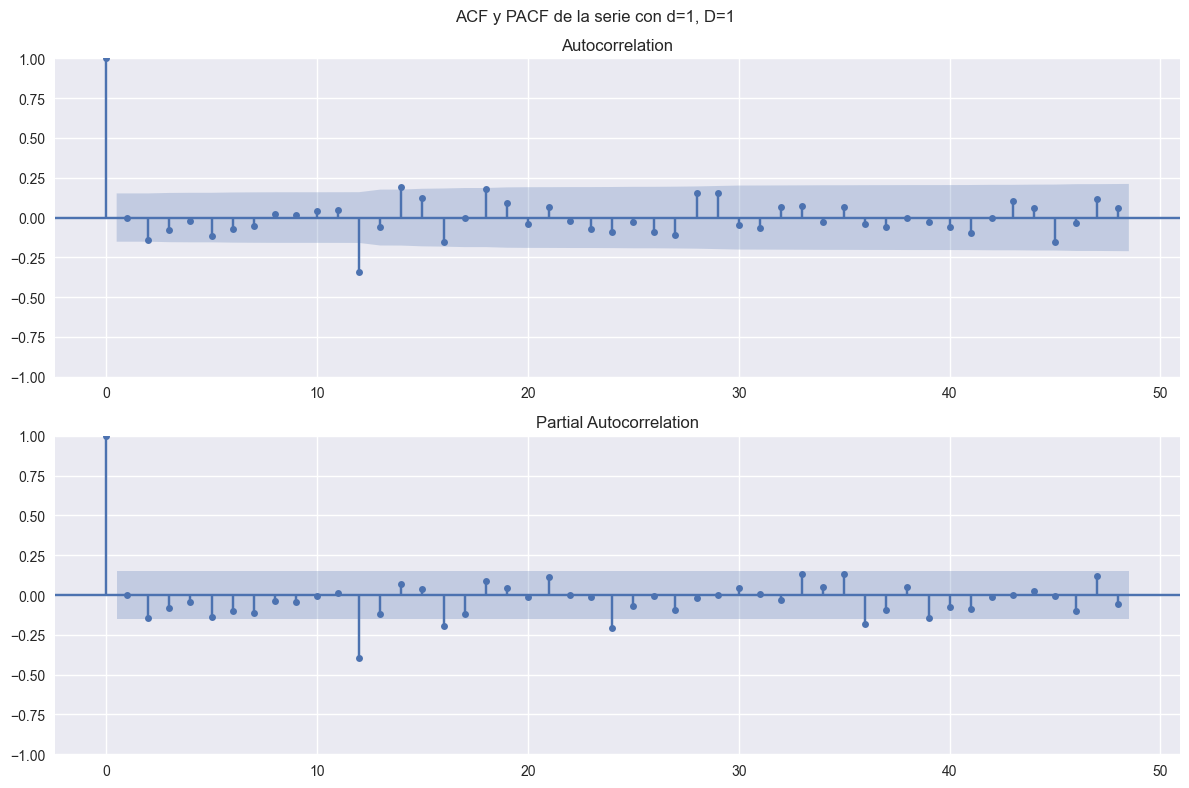

In [12]:
# Correlogramas de la serie doblemente diferenciada
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_diff_12_1, ax=ax[0], lags=48)
plot_pacf(train_diff_12_1, ax=ax[1], lags=48)
plt.suptitle('ACF y PACF de la serie con d=1, D=1')
plt.tight_layout()
plt.show()

**Decisión del modelo manual:**
- **d=1, D=1:** Parece necesario diferenciar estacionalmente y regularmente para estabilizar la media y eliminar la estacionalidad.
- **p, q, P, Q:** En series mensuales tipo "Airline", es común encontrar un modelo $(0, 1, 1) \times (0, 1, 1)_{12}$.
- Esto se justifica si vemos un corte significativo en el lag 1 de la ACF (para q=1) y en el lag 12 de la ACF (para Q=1), con decrecimiento en la PACF.
- Vamos a ajustar este modelo clásico como punto de partida robusto.

In [13]:
# Ajuste Manual: SARIMA(0, 1, 1)x(0, 1, 1, 12)
manual_order = (0, 1, 1)
manual_seasonal_order = (0, 1, 1, 12)

print(f"Ajustando modelo manual SARIMA{manual_order}x{manual_seasonal_order}...")
model_manual = SARIMAX(train, order=manual_order, seasonal_order=manual_seasonal_order)
results_manual = model_manual.fit(disp=False)

print(results_manual.summary())


Ajustando modelo manual SARIMA(0, 1, 1)x(0, 1, 1, 12)...
                                     SARIMAX Results                                      
Dep. Variable:                             extent   No. Observations:                  180
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -20.581
Date:                            Sun, 08 Mar 2026   AIC                             47.163
Time:                                    12:39:35   BIC                             56.517
Sample:                                01-01-2010   HQIC                            50.959
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0705      0.069     -1.016      0.310   

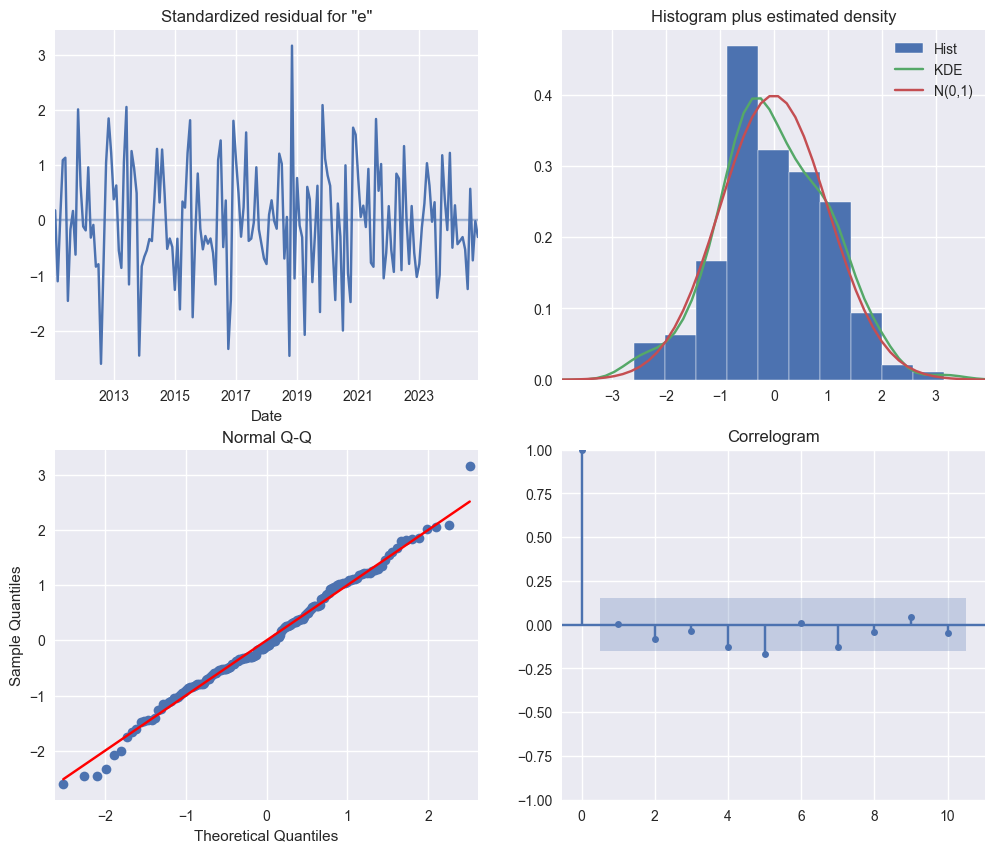


Test de Ljung-Box (p-values):
      lb_stat  lb_pvalue
12  37.148171   0.000211
24  37.624869   0.037863


In [14]:
# Diagnóstico de residuos
results_manual.plot_diagnostics(figsize=(12, 10))
plt.show()

# Test de Ljung-Box para incorrelación de residuos
# Comprobamos si los residuos son ruido blanco (p-value > 0.05)
lb_test = acorr_ljungbox(results_manual.resid, lags=[12, 24], return_df=True)
print("\nTest de Ljung-Box (p-values):")
print(lb_test)

## 6. Ajuste Automático (Auto ARIMA) y Selección
Utilizamos `auto_arima` para buscar el modelo óptimo barriendo diferentes combinaciones de parámetros y minimizando el AIC.

In [15]:
model_auto = pm.auto_arima(train, 
                           seasonal=True, m=12,
                           d=1, D=1,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3, max_P=3, max_Q=3,
                           trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

print("\nMejor modelo encontrado por Auto ARIMA:")
print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=43.041, Time=0.32 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=88.520, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=70.481, Time=0.12 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=47.163, Time=0.23 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=45.838, Time=0.14 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=68.484, Time=0.09 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=45.041, Time=0.61 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=45.041, Time=0.68 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=43.300, Time=0.76 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=59.148, Time=0.19 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=inf, Time=1.67 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=44.665, Time=0.51 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=44.559, Time=0.47 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=1.19 sec
 ARIMA(0,1,0)(1,1,1)[12] intercept   : AIC=45.021, Ti

In [16]:
# Comparación de modelos
aic_manual = results_manual.aic
aic_auto = model_auto.aic()

print(f"\nAIC Manual: {aic_manual:.4f}")
print(f"AIC Auto: {aic_auto:.4f}")

if aic_auto < aic_manual:
    best_arima_model = model_auto
    print("-> El modelo Auto ARIMA es mejor (menor AIC).")
else:
    best_arima_model = results_manual # Nota: Si gana manual, usaremos el objeto results_manual
    print("-> El modelo Manual es mejor o igual (menor AIC).")


AIC Manual: 47.1628
AIC Auto: 43.0413
-> El modelo Auto ARIMA es mejor (menor AIC).


## 7. Expresión Algebraica del Modelo Óptimo
Escribimos los parámetros estimados del mejor modelo.

In [17]:
if aic_auto < aic_manual:
    # Ajustamos un SARIMAX con los parametros de auto_arima para tener consistencia en los objetos
    final_order = model_auto.order
    final_seasonal_order = model_auto.seasonal_order
    final_model = SARIMAX(train, order=final_order, seasonal_order=final_seasonal_order).fit(disp=False)
else:
    final_order = manual_order
    final_seasonal_order = manual_seasonal_order
    final_model = results_manual

print(f"\nModelo Final Seleccionado: SARIMA{final_order}x{final_seasonal_order}")
print("Coeficientes estimados:")
print(final_model.params)



Modelo Final Seleccionado: SARIMA(0, 1, 0)x(1, 1, 1, 12)
Coeficientes estimados:
ar.S.L12    0.232451
ma.S.L12   -0.876503
sigma2      0.067799
dtype: float64


**Expresión Algebraica General:**
(1 - \phi_1 B - ... - \phi_p B^p)(1 - \Phi_1 B^{12} - ... - \Phi_P B^{12P}) (1-B)^d (1-B^{12})^D y_t = (1 + \theta_1 B + ... + \theta_q B^q)(1 + \Theta_1 B^{12} + ... + \Theta_Q B^{12Q}) \epsilon_t
 
Sustituyendo los valores de `final_model.params` en la ecuación anterior obtenemos la expresión concreta.

## 8. Predicciones e Intervalos de Confianza

In [18]:
# Predicción sobre el conjunto de test (12 meses)
forecast_object = final_model.get_prediction(start=test.index[0], end=test.index[-1])
predictions_arima = forecast_object.predicted_mean
conf_int_arima = forecast_object.conf_int(alpha=0.05) # 95% confianza (alpha=0.05)

print("\nTabla de Predicciones ARIMA y Test:")
pred_table_arima = pd.DataFrame({
    'Observado': test,
    'Predicción ARIMA': predictions_arima,
    'IC Inferior': conf_int_arima.iloc[:, 0],
    'IC Superior': conf_int_arima.iloc[:, 1]
})
print(pred_table_arima)



Tabla de Predicciones ARIMA y Test:
            Observado  Predicción ARIMA  IC Inferior  IC Superior
2025-01-01      13.11         13.128771    12.617150    13.640393
2025-02-01      13.75         13.923061    13.199732    14.646389
2025-03-01      14.12         14.158292    13.272486    15.044098
2025-04-01      13.83         13.413581    12.390791    14.436372
2025-05-01      12.49         12.106797    10.963317    13.250278
2025-06-01      10.40         10.268200     9.015605    11.520796
2025-07-01       7.66          7.377001     6.024062     8.729940
2025-08-01       5.39          4.848475     3.402138     6.294812
2025-09-01       4.75          3.978542     2.444483     5.512602
2025-10-01       6.32          5.712942     4.095912     7.329973
2025-11-01       8.77          8.881283     7.185337    10.577230
2025-12-01      11.22         11.201746     9.430395    12.973096


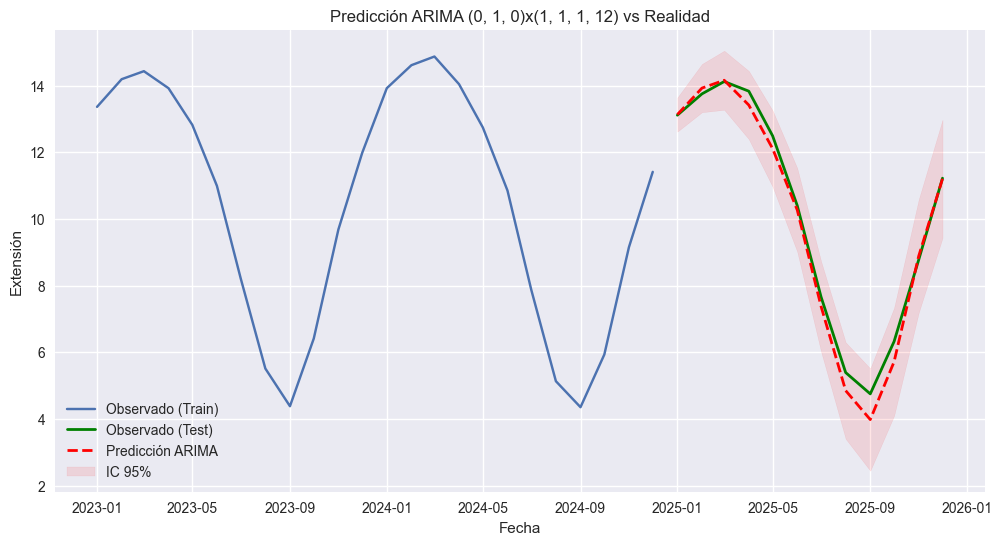

In [19]:
plt.figure(figsize=(12, 6))
# Mostramos últimos 2 años de train para contexto
plt.plot(train.index[-24:], train.iloc[-24:], label='Observado (Train)')
plt.plot(test.index, test, label='Observado (Test)', color='green', linewidth=2)
# Predicción ARIMA
plt.plot(predictions_arima.index, predictions_arima, label='Predicción ARIMA', color='red', linestyle='--', linewidth=2)
# Intervalo de confianza
plt.fill_between(predictions_arima.index, 
                 conf_int_arima.iloc[:, 0], 
                 conf_int_arima.iloc[:, 1], 
                 color='red', alpha=0.1, label='IC 95%')

plt.title(f'Predicción ARIMA {final_order}x{final_seasonal_order} vs Realidad')
plt.xlabel('Fecha')
plt.ylabel('Extensión')
plt.legend()
plt.show()

## 9. Comparación de Métodos y Conclusiones
Comparamos el modelo de Suavizado Exponencial (apartado 4) con el modelo ARIMA elegido.

- Recopilamos las predicciones de ETS (calculadas en la sección 4)
- predictions_ets está disponible en el entorno

In [20]:
# Calculamos métricas de error
rmse_ets = np.sqrt(mean_squared_error(test, predictions_ets))
rmse_arima = np.sqrt(mean_squared_error(test, predictions_arima))

mae_ets = np.mean(np.abs(test - predictions_ets))
mae_arima = np.mean(np.abs(test - predictions_arima))

print(f"RMSE Suavizado Exponencial: {rmse_ets:.4f}")
print(f"RMSE Modelo ARIMA:          {rmse_arima:.4f}")
print("-" * 40)
print(f"MAE Suavizado Exponencial:  {mae_ets:.4f}")
print(f"MAE Modelo ARIMA:           {mae_arima:.4f}")

# Tabla comparativa final
comparison_df = pd.DataFrame({
    'Fecha': test.index,
    'Real': test.values,
    'Pred_ETS': predictions_ets.values,
    'Pred_ARIMA': predictions_arima.values,
    'AbsErr_ETS': np.abs(test.values - predictions_ets.values),
    'AbsErr_ARIMA': np.abs(test.values - predictions_arima.values)
}).set_index('Fecha')

print("\nDetalle de errores por mes:")
print(comparison_df)

RMSE Suavizado Exponencial: 0.3554
RMSE Modelo ARIMA:          0.3785
----------------------------------------
MAE Suavizado Exponencial:  0.2962
MAE Modelo ARIMA:           0.2912

Detalle de errores por mes:
             Real   Pred_ETS  Pred_ARIMA  AbsErr_ETS  AbsErr_ARIMA
Fecha                                                             
2025-01-01  13.11  13.026457   13.128771    0.083543      0.018771
2025-02-01  13.75  13.824465   13.923061    0.074465      0.173061
2025-03-01  14.12  14.051653   14.158292    0.068347      0.038292
2025-04-01  13.83  13.388744   13.413581    0.441256      0.416419
2025-05-01  12.49  12.104208   12.106797    0.385792      0.383203
2025-06-01  10.40  10.252994   10.268200    0.147006      0.131800
2025-07-01   7.66   7.373146    7.377001    0.286854      0.282999
2025-08-01   5.39   4.929445    4.848475    0.460555      0.541525
2025-09-01   4.75   4.024743    3.978542    0.725257      0.771458
2025-10-01   6.32   5.849637    5.712942    0.470363 

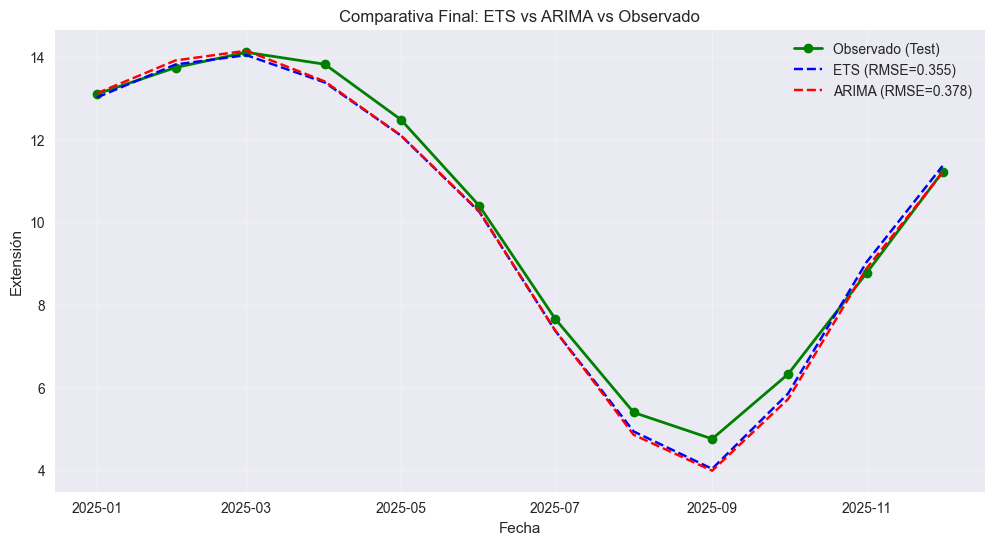

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Observado (Test)', color='green', linewidth=2, marker='o')
plt.plot(predictions_ets.index, predictions_ets, label=f'ETS (RMSE={rmse_ets:.3f})', color='blue', linestyle='--')
plt.plot(predictions_arima.index, predictions_arima, label=f'ARIMA (RMSE={rmse_arima:.3f})', color='red', linestyle='--')

plt.title('Comparativa Final: ETS vs ARIMA vs Observado')
plt.xlabel('Fecha')
plt.ylabel('Extensión')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Conclusión Final:**
El análisis de los errores RMSE y MAE nos permite determinar qué método ha generalizado mejor.
- Si RMSE_ARIMA < RMSE_ETS: El modelo ARIMA ha capturado mejor la estructura de la serie.
- Si RMSE_ETS < RMSE_ARIMA: El método de Holt-Winters ha sido más efectivo para este horizonte de predicción.